# Staking

In [84]:
from sklearn.ensemble import StackingClassifier
import joblib
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

In [85]:
seed = 42

In [86]:
dataset = pd.read_csv("./datasets/thyroid0387_balanced.data", sep = ";", index_col="Unnamed: 0")

In [87]:
numeric_col = dataset.select_dtypes(include = ["int64", "float64"]).columns

scaler = StandardScaler()
dataset[numeric_col] = scaler.fit_transform(dataset[numeric_col])

In [88]:
dataset.head()

,age,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,...,T4U_value,FTI_value,TBG_value,ref_STMW,ref_SVHC,ref_SVHD,ref_SVI,ref_WEST,ref_other,diagnosis_group
0,-1.212790,False,False,False,False,False,False,False,True,False,...,-0.152529,-0.180795,1.046431,False,False,False,False,False,True,normal
1,-1.212790,False,False,False,False,False,False,False,False,False,...,-0.116076,0.181697,-0.825246,False,False,False,False,False,True,normal
2,-0.569556,False,False,False,False,False,False,False,False,True,...,-0.985641,0.014618,-2.723338,False,False,False,False,False,True,normal
3,-0.837570,False,False,False,False,False,False,False,False,False,...,0.072594,-0.236669,-0.069598,False,False,False,False,False,True,normal
4,-1.051981,False,False,False,False,False,False,False,False,False,...,-0.798453,-0.027173,1.699562,False,False,False,False,False,True,misc


In [89]:
label = LabelEncoder()
dataset["diagnosis_group"] = label.fit_transform(dataset["diagnosis_group"])

print(f"{dict(enumerate(label.classes_))}")

{0: 'antithyroid_treatment', 1: 'binding_protein', 2: 'general_health', 3: 'hyperthyroid', 4: 'hypothyroid', 5: 'misc', 6: 'normal', 7: 'replacement_therapy'}


In [90]:
x = dataset.drop(columns=["diagnosis_group"])
y = dataset["diagnosis_group"]

In [91]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = seed)

In [92]:
print(f"X train: {x_train.shape}\nX test: {x_test.shape}\nY train: {y_train.shape}\nY test: {y_test.shape}")

X train: (36097, 28)
X test: (15471, 28)
Y train: (36097,)
Y test: (15471,)


# Stacking

In [93]:
xgboost = XGBClassifier()
xgboost.load_model("./models_saved/xgboost_opt.json")
svm = joblib.load("./models_saved/svm_opt.json")    
random_forest = joblib.load("./models_saved/randforest_opt.json")
#neural_network = joblib.load("./models_saved/xxnn.json")
logistic_regression = joblib.load("./models_saved/logregression_opt.json")

knn = joblib.load("./models_saved/knn_opt.json")
catboost = CatBoostClassifier().load_model("./models_saved/catboost_opt.json")

In [94]:
stacking = StackingClassifier(
    estimators=[
        ("xgboost", xgboost),
        ("svm", svm),
        ("random_forest", random_forest),
        #("neural_network", neural_network),
        ("logistic_regression", logistic_regression),
        ("knn", knn),
        ("catboost", catboost)
    ], 
    final_estimator = XGBClassifier(),
    cv = 5,
    n_jobs = -1
)

In [95]:
stacking.fit(x_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('xgboost',
                                XGBClassifier(base_score='5E-1',
                                              booster='gbtree', callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=None,
                                              feature_types=['int', 'i', 'i',
                                                             'i', 'i', 'i', 'i',
                                                             'i', 'i', 'i', 'i',
                                                             'i', 'i', 'i', 'i',
                                                             'i', 'float',
                                                             'f...
                                                 gamma=None, grow_policy=None,
                                                 importance_type=None,
                                                 interaction_constraints=None,
                                                 learning_rate=None,
                                                 max_bin=None,
                                                 max_cat_threshold=None,
                                                 max_cat_to_onehot=None,
                                                 max_delta_step=None,
                                                 max_depth=None,
                                                 max_leaves=None,
                                                 min_child_weight=None,
                                                 missing=nan,
                                                 monotone_constraints=None,
                                                 multi_strategy=None,
                                                 n_estimators=None, n_jobs=None,
                                                 num_parallel_tree=None, ...),
                   n_jobs=-1)

In [96]:
y_pred = stacking.predict(x_test)

## Staking evaluation

Accuracy: 0.9994829034968651
F1 score: 0.9994827867878526


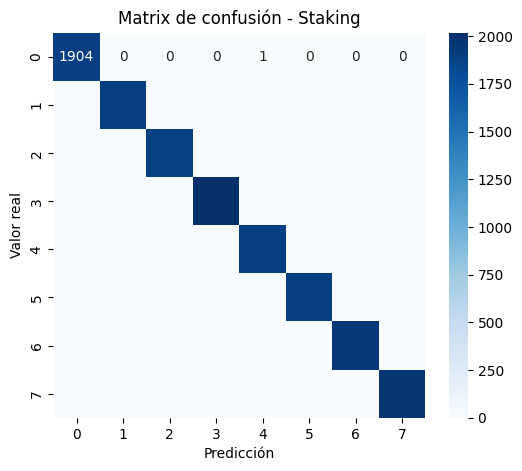

In [97]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1 score: {f1_score(y_test, y_pred, average = 'weighted')}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matrix de confusión - Staking')
plt.show()


In [98]:
joblib.dump(stacking, "./models_saved/stacking_model.pkl")

['./models_saved/stacking_model.pkl']